<a href="https://colab.research.google.com/github/DrTkachuk/RobustnessOfTensegrityFormFindingViaRankMinimization/blob/main/TensegrityExample4_10node_plane_with_18members.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook implements an example 4

Reproduces figure 9 (left)

Tkachuk, A. (2022). Robustness of rank minimization heuristics for form-finding of tensegrity structures. Computers & Structures, 266, 106786.

In [1]:
import numpy as np
from numpy.linalg import matrix_rank
import cvxpy as cp

In [2]:
# Input
nele = 18
nnode = 10
# connectivity matrix
ID = np.array([[1, 3], [2, 9], [1, 4], [2, 10], [3, 5], [7, 9], [4, 6], [8, 10], [3, 6], [7, 10], [5, 7], [6, 7], [6, 8], [3, 4], [9, 10], [5, 6], [7, 8], [1, 2] ])
print(ID)
# dummy flag for vizualization - 1 means green dashed line or dummy truss
dummyflag = np.array([0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 1])
# sign of force densities: +1 - cabel/tension; -1 - compression
SigM = np.diag([1,1,1,1,1, 1,1,1,1,1, 1,1,1, -1,-1,-1,-1,-1])
print(dummyflag)
#prescribed nodal location, always last 3 nodes
xbar=np.array([-5.0,5.0,-2.0])
ybar=np.array([0,0,1.4])
#sign offset for the force densities
epsilon=0.01
#parameter of log-det heuristics
delta=0.0001
num_iter=5
#tolerance for rank definition
rank_tol = 1e-7

[[ 1  3]
 [ 2  9]
 [ 1  4]
 [ 2 10]
 [ 3  5]
 [ 7  9]
 [ 4  6]
 [ 8 10]
 [ 3  6]
 [ 7 10]
 [ 5  7]
 [ 6  7]
 [ 6  8]
 [ 3  4]
 [ 9 10]
 [ 5  6]
 [ 7  8]
 [ 1  2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [3]:
#node-edge incidence matrix
C = np.zeros((nnode,nele))
for i in range(nele):
    C[ID[i,0]-1,i] = -1
    C[ID[i,1]-1,i] = 1
print(C)

[[-1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.]
 [ 0. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.]
 [ 1.  0.  0.  0. -1.  0.  0.  0. -1.  0.  0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  1.  0.  0. -1. -1.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.  0. -1.  1.  1.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  1.  0.  0.  0.  1.  0.]
 [ 0.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  1.  0.  1.  0.  0.  0.  0.  1.  0.  0.  0.]]


In [4]:
# definition of cvxpy problem
# force densities are the only variables
Q = cp.Variable(nele)

# initialization of weighting matrix
W = np.eye(nnode,nnode)
#rank history
rank_hist=[]

for i in range(num_iter):
    # definition of cost and constraints
    cost=cp.trace(W @ C @ cp.diag(Q) @ C.T)
    constraints = [epsilon <= SigM @ Q, cp.PSD(C @ cp.diag(Q) @ C.T)]
    # creating problem object
    prob = cp.Problem(cp.Minimize(cost), constraints=constraints)
    prob.solve()
    #history of rank change
    rank_hist.append(int(matrix_rank (C @ np.diag(Q.value) @ C.T, tol=rank_tol, hermitian=True)))
    #updating the weight
    W =np.linalg.inv( C @ np.diag(Q.value) @ C.T + delta * np.eye(nnode,nnode))

print(Q.value/epsilon)
print(rank_hist)




[ 3.00627065  1.94373638  1.94373638  3.00627065  1.          1.92320899
  1.92320899  1.          2.05568086  2.05568086  1.          3.15361586
  1.         -1.99771749 -1.99771749 -1.0001408  -1.0001408  -1.        ]
[9, 7, 7, 7, 7]


In [5]:
rank_achieved= matrix_rank (C @ np.diag(Q.value) @ C.T, tol=rank_tol, hermitian=True)

In [6]:
# recovery of the geometry from the nullspace of the force density matrix
# first, full SVD decompostion
U, S, Vh = np.linalg.svd(C @ np.diag(Q.value) @ C.T, full_matrices=True,hermitian=True)

In [7]:
#slicing the vectors and finding equations
phi = U[:,(nnode-3):nnode]
Kgeom=phi[0:3,:]
# finding the nodal position as linear combination of the nulspace vectors
alpha = np.linalg.solve(Kgeom,xbar)
beta = np.linalg.solve(Kgeom,ybar)
# final vector of nodal positions
xstar= phi @ alpha
ystar= phi @ beta
print(xstar)
print(ystar)

[-5.          5.         -2.         -4.49520517  0.78660411 -1.3931486
  1.3931486  -0.78660411  4.49520517  2.        ]
[ 3.76562229e-17  2.68472999e-17  1.40000000e+00 -2.16530335e+00
  2.70104909e+00 -6.50288612e-01  6.50288612e-01 -2.70104909e+00
  2.16530335e+00 -1.40000000e+00]


In [8]:
#check recovering geometry to fullfil the homogeneous equilibrium conditions
print(np.linalg.norm(C @ np.diag(Q.value) @ C.T @ xstar))
print(np.linalg.norm(C @ np.diag(Q.value) @ C.T @ ystar))

2.729834193593155e-10
2.093547418326976e-10


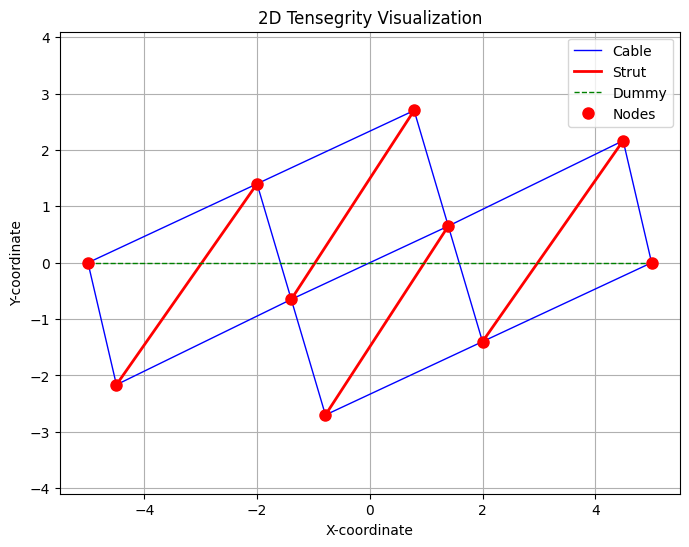

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

cable_label_added = False
strut_label_added = False
dummy_label_added = False

for i in range(nele):
    node1 = ID[i, 0] - 1  # Adjust for 0-based indexing
    node2 = ID[i, 1] - 1  # Adjust for 0-based indexing

    x_coords = [xstar[node1], xstar[node2]]
    y_coords = [ystar[node1], ystar[node2]]

    if SigM[i,i] == 1:
        label = 'Cable' if not cable_label_added else ''
        plt.plot(x_coords, y_coords, 'b-', linewidth=1, label=label)
        cable_label_added = True
    elif dummyflag[i] == 0:
        label = 'Strut' if not strut_label_added else ''
        plt.plot(x_coords, y_coords, 'r-', linewidth=2, label=label )
        strut_label_added = True
    else:
        label = 'Dummy' if not dummy_label_added else ''
        plt.plot(x_coords, y_coords, 'g--', linewidth=1, label=label)
        dummy_label_added = True

# Plot nodes
plt.plot(xstar, ystar, 'ro', markersize=8, label='Nodes')

plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.title('2D Tensegrity Visualization')
plt.grid(True)
plt.axis('equal') # Ensure proper aspect ratio for 2D structure
plt.legend()
plt.show()